In [1]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [2]:
dataset_path = kagglehub.dataset_download('haejeg1/m-data')

100%|██████████| 172M/172M [00:07<00:00, 23.9MB/s]

Extracting files...


In [3]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Create dataframes from data
files = os.listdir(dataset_path)
print(files)

immigrations_df = pd.read_csv(os.path.join(dataset_path, files[0]))
removals_df = pd.read_csv(os.path.join(dataset_path, files[1]))
net_migrations_df = pd.read_csv(os.path.join(dataset_path, files[2]))
arrests_df = pd.read_csv(os.path.join(dataset_path, files[3]))

['immigrations.csv', 'removals.csv', 'net_migrations.csv', 'arrests.csv']


In [5]:
# Convert into a readable number data
immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'] = immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Removals'] = immigrations_df['Noncitizen Removals'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Apprehensions'] = immigrations_df['Noncitizen Apprehensions'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Refugee Arrivals'] = immigrations_df['Refugee Arrivals'].astype(str).str.replace(',', '', regex=False).astype(int)
immigrations_df['Noncitizen Returns'] = immigrations_df['Noncitizen Returns'].astype(str).str.replace(',', '', regex=False).astype(int)

In [6]:
immigrations_df.rename(columns={'Year': 'year'}, inplace=True)
immigrations_df['year'] = immigrations_df['year'].astype(int)
net_migrations_df['year'] = net_migrations_df['year'].astype(int)

# Merge dataframes
merged_df = pd.merge(immigrations_df, net_migrations_df, on='year', how='inner')
merged_df

,Unnamed: 0_x,year,Immigrants Obtaining Lawful Permanent Resident Status,Refugee Arrivals,Noncitizen Apprehensions,Noncitizen Removals,Noncitizen Returns,Unnamed: 0_y,country,population,netMigration,population_in_millions
0,32,2012,1031631,58179,795735,415579,231105,11467,United States,313877662.0,1323368.0,313
1,33,2013,990553,69909,786223,432201,178973,11466,United States,316059947.0,1320840.0,316
2,34,2014,1016518,69975,805334,405026,163836,11465,United States,318386329.0,1250914.0,318
3,35,2015,1051031,69920,596560,324303,129636,11464,United States,320738994.0,1221849.0,320
4,36,2016,1183505,84989,683782,332263,106479,11463,United States,323071755.0,1449371.0,323
5,37,2017,1127167,53691,607677,284298,100454,11462,United States,325122128.0,1377630.0,325
6,38,2018,1096611,22405,739486,327554,159960,11461,United States,326838199.0,1200796.0,326
7,39,2019,1031765,29916,1175841,347183,171125,11460,United States,328329953.0,1158444.0,328
8,40,2020,707362,11840,609265,237861,167453,11459,United States,331526933.0,675560.0,331
9,41,2021,740002,11454,1865379,89191,178227,11458,United States,332048977.0,561580.0,332


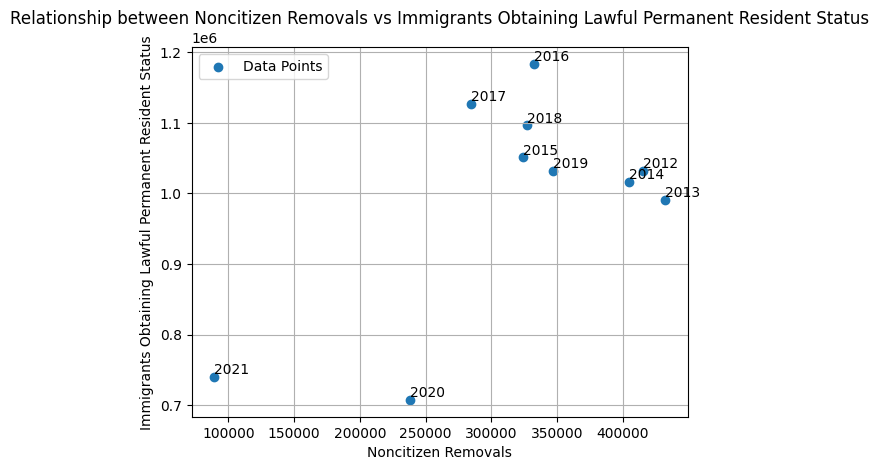

In [12]:
import matplotlib.pyplot as plt

# Looking at whether or not there's a relationship between noncitizen removals
# and immigrants obtaining lawful permanent resident status
plt.scatter(immigrations_df['Noncitizen Removals'], immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'], label='Data Points')

plt.xlabel('Noncitizen Removals')
plt.ylabel('Immigrants Obtaining Lawful Permanent Resident Status')
plt.title('Relationship between Noncitizen Removals vs Immigrants Obtaining Lawful Permanent Resident Status')
plt.legend()
plt.grid(True)
# plt.show() # Removed to allow adding text before showing

# I'm not sure if this can be considered too useful, as high immigration years could
# lead to more deportations.

for i, year in enumerate(immigrations_df['year']):
    plt.text(immigrations_df['Noncitizen Removals'][i], immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'][i], str(year), ha='left', va='bottom')

plt.show()

In [14]:
X = merged_df[['Immigrants Obtaining Lawful Permanent Resident Status', 'Noncitizen Removals', 'Noncitizen Apprehensions']]
y = merged_df['netMigration']

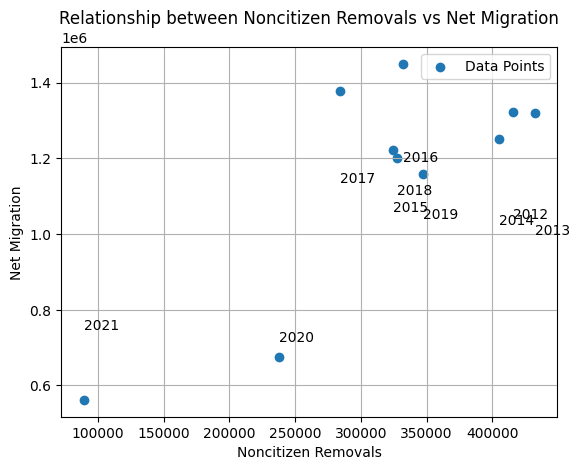

In [17]:
# This time I'll try using World Bank API's migration data
plt.scatter(X['Noncitizen Removals'], y, label='Data Points')

plt.xlabel('Noncitizen Removals')
plt.ylabel('Net Migration')
plt.title('Relationship between Noncitizen Removals vs Net Migration')
plt.legend()
plt.grid(True)

for i, year in enumerate(immigrations_df['year']):
    plt.text(immigrations_df['Noncitizen Removals'][i], immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'][i], str(year), ha='left', va='bottom')

plt.show()
# This seems to show about the same trend as the last graph.

In [18]:
# Now I'm checking if there are non surface level data trends.
# I'm gonna start by using ICE removal data, and adding a Year column so
# if I ever need to merge these with the other ones I can do so.
print(removals_df.columns)
removals_df['Apprehension Date']
new_removals_df = removals_df
new_removals_df['Apprehension Date'] = pd.to_datetime(new_removals_df['Apprehension Date'], errors='coerce')
new_removals_df['Year'] = new_removals_df['Apprehension Date'].dt.year

Index(['Unnamed: 0', 'Departure Date', 'Port of Departure',
       'Departure Country', 'Case Status', 'Case Category',
       'Final Order Yes No', 'Final Order Date', 'Case ID', 'Gender',
       'Birth Country', 'Citizenship Country', 'Birth Date', 'Birth Year',
       'Alien File Number', 'Entry Status', 'Entry Date', 'MSC Charge',
       'MSC Charge Date', 'MSC Charge Code', 'MSC Conviction Date',
       'MSC Criminal Charge Status', 'Case Threat Level',
       'Processing Disposition Code', 'Processing Disposition',
       'Current Program', 'Apprehension Date', 'Charge Section Code',
       'Charge Code', 'Anonymized Identifier'],
      dtype='object')


In [19]:
# Starting with checking country specific cases
removal_cases = new_removals_df[new_removals_df['Case Status'].str.contains('Deported|Removed', case=False, na=False)]

top_10_countries = removal_cases['Departure Country'].value_counts().head(10)

print(top_10_countries)

Departure Country
MEXICO                1236525
GUATEMALA              348964
HONDURAS               240733
EL SALVADOR            151374
DOMINICAN REPUBLIC      12918
ECUADOR                 12861
BRAZIL                  10394
NICARAGUA               10073
HAITI                    9343
COLOMBIA                 7510
Name: count, dtype: int64


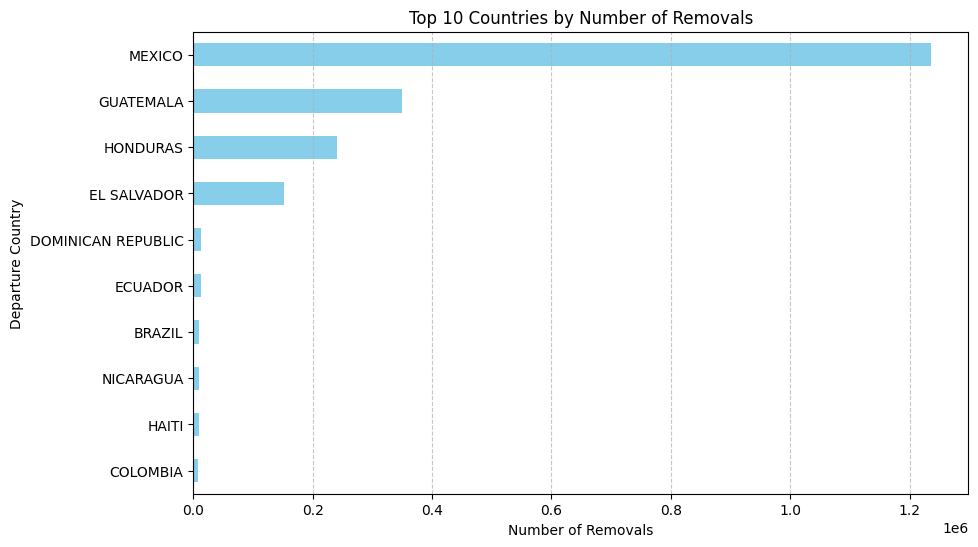

In [20]:
# Visualizing time :D
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='barh', color='skyblue')

plt.title('Top 10 Countries by Number of Removals')
plt.xlabel('Number of Removals')
plt.ylabel('Departure Country')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
# I think the data makes sense, there's definitely a good amount of Latin American
# immigration visible on a day to day basis.

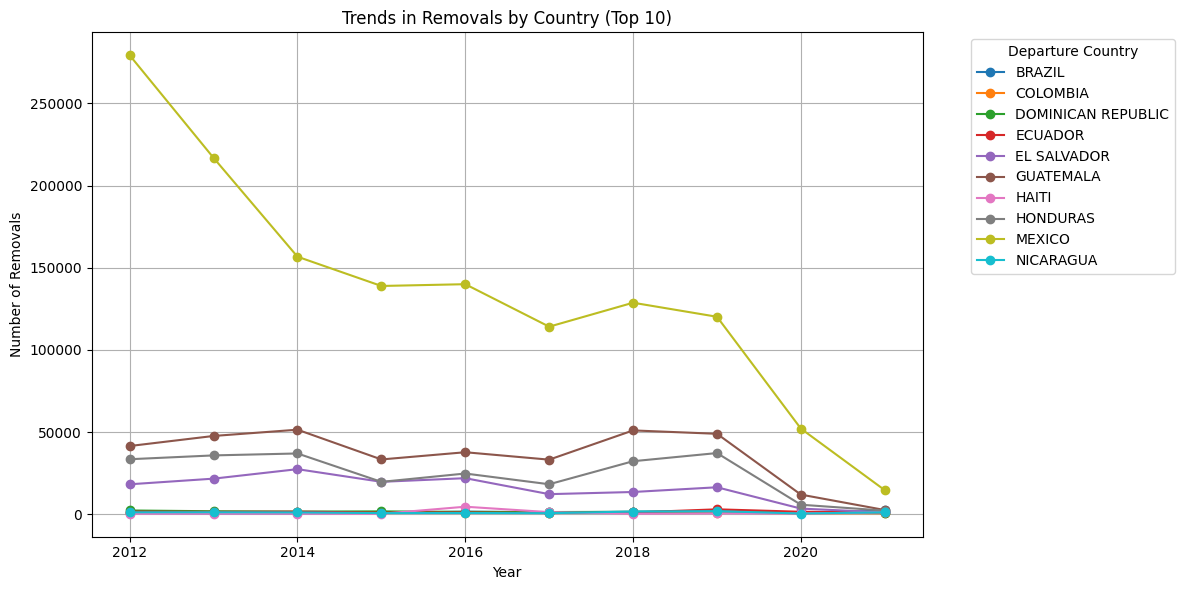

In [21]:
# Let's graph how these countries changed over time
top_10_df = new_removals_df[new_removals_df['Departure Country'].isin(top_10_countries.index)]

trend_data = top_10_df.groupby(['Year', 'Departure Country']).size().unstack()

trend_data.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Trends in Removals by Country (Top 10)')
plt.xlabel('Year')
plt.ylabel('Number of Removals')
plt.legend(title='Departure Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# This graph really surprised me, I'm guessing that last drop off from 2020-21
# is due to COVID. However, I'm surprised that Trump (2017 - 2021), who campaigned
# on enforcing illegal immigration had less ICE removals than Obama (2012 - 2017)
# it really sucks that the data cut off is 2021. If there was political bias
# wouldn't Trump want to show that he has MORE removals than Obama did..?

In [24]:
# The COVID years seem like an outlier so I feel like we should remove them

non_covid_merged_df = merged_df[~merged_df['year'].isin([2020, 2021])]
non_covid_removals_df = new_removals_df[~new_removals_df['Year'].isin([2020, 2021])]

immigrations_df = immigrations_df[~immigrations_df['year'].isin([2020, 2021])]

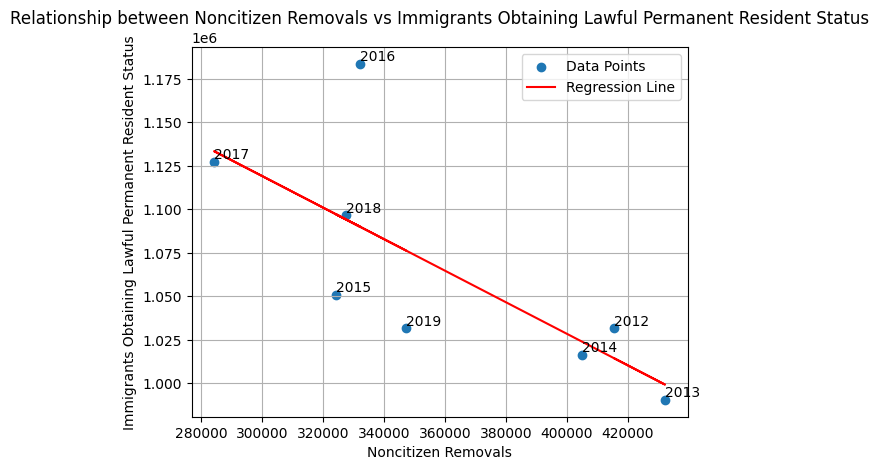

In [26]:
# Graphing the new non covid years data to see what it looks like

X_reg = non_covid_merged_df[['Noncitizen Removals']]
y_reg = non_covid_merged_df['Immigrants Obtaining Lawful Permanent Resident Status']

model = LinearRegression()
model.fit(X_reg, y_reg)

y_pred = model.predict(X_reg)

plt.scatter(non_covid_merged_df['Noncitizen Removals'], non_covid_merged_df['Immigrants Obtaining Lawful Permanent Resident Status'], label='Data Points')
plt.plot(X_reg, y_pred, color='red', label='Regression Line')

plt.xlabel('Noncitizen Removals')
plt.ylabel('Immigrants Obtaining Lawful Permanent Resident Status')
plt.title('Relationship between Noncitizen Removals vs Immigrants Obtaining Lawful Permanent Resident Status')
plt.legend()
plt.grid(True)
for i, year in enumerate(immigrations_df['year']):
    plt.text(immigrations_df['Noncitizen Removals'][i], immigrations_df['Immigrants Obtaining Lawful Permanent Resident Status'][i], str(year), ha='left', va='bottom')

plt.show()

# This could be really selective data selection, but conceptually this makes more sense
# to me than the one with the covid years.

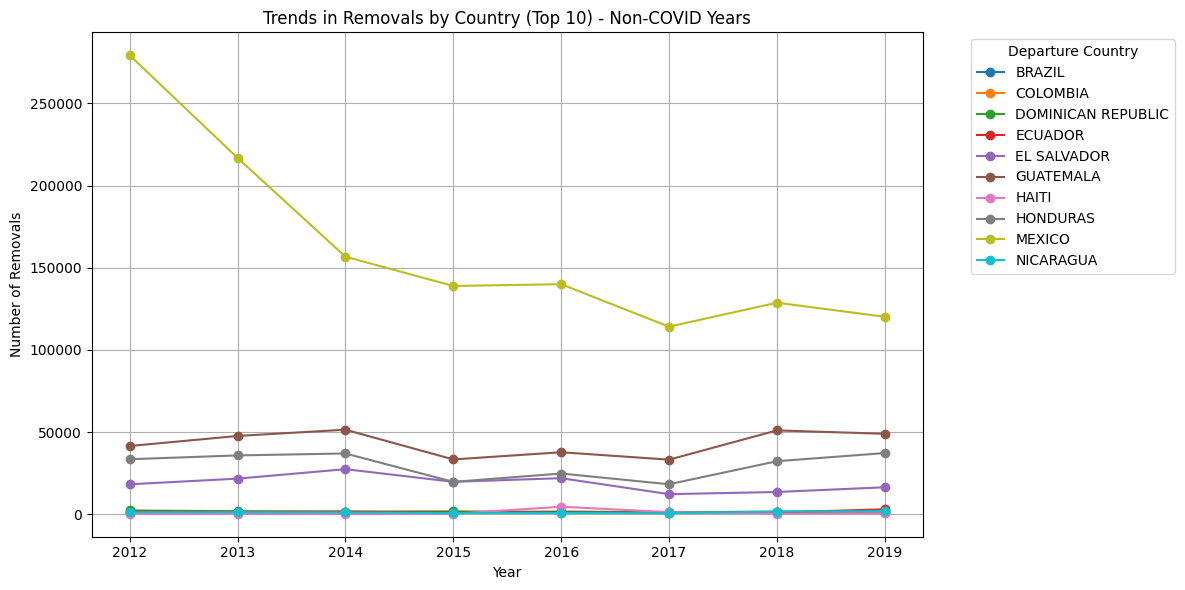

In [27]:
top_10_df = non_covid_removals_df[non_covid_removals_df['Departure Country'].isin(top_10_countries.index)]

trend_data = top_10_df.groupby(['Year', 'Departure Country']).size().unstack()

trend_data.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Trends in Removals by Country (Top 10) - Non-COVID Years')
plt.xlabel('Year')
plt.ylabel('Number of Removals')
plt.legend(title='Departure Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# What I still don't understand is why there is a huge spike in 2012
# what externals factors could have caused that?? Or was that just a really
# active ICE year?

In [ ]:
# It's a hard to draw line separating data from politics from this point on,
# but essentially 2012 was not an outlier, and seems like it was from technology
# getting better.

# https://www.ice.gov/news/releases/fy-2012-ice-announces-year-end-removal-numbers-highlights-focus-key-priorities-and#:~:text=To%20support%20DHS'%20efforts%20to,removal%20of%20recent%20border%20crossers.

# Although no solid concrete source on this like a .gov website, it seems like Obama
# also may have changed the label of border returnees to removals, so it may be a good
# idea to sum the two for future data comparisons.